# FAM vs corner-WFS correlations at the 4 corners (v2)

**Author:** Aaron Roodman  
**Date Created:** 2026-07-07  
**Last Modified:** 2026-07-07  
**Status:** In Progress  
**Keywords:** AOS, corner WFS, FAM, Zernike, correlation, Huber  

## Description

Reproduces the first 9 pages of the `wfs_corner_compare` step's PDF
(`output/<ps>/wfs/<cwfs>/wfs_corner_compare.pdf`) from its tidy parquet, so the
corner-by-corner FAM-vs-CWFS comparison can be explored interactively for any
CWFS variant (`refitWcs`, `paired_3mm`, `ai_donut`).

For each FAM triplet, corner raft (R00/R04/R40/R44) and Noll Zernike j the parquet
holds the FAM measured OPD interpolated to the corner azimuth (`fam_interp`) and
the CWFS median there (`cwfs_median`), plus sidecar columns
(rotator_angle, alt_deg, az_deg, mjd, science_program).

Pages reproduced:
1. Per-corner FAM-vs-CWFS scatter, all Zj (4 figures) — Huber robust fit line,
   with Pearson r + Spearman rho + slope/offset/robust-RMS per panel.
2. Per-corner time history vs image ordinal, all Zj (4 figures).
3. Summary: Pearson r / Spearman rho / Huber slope / offset / robust RMS vs Zj,
   all 4 corners (1 figure).

**Output:** inline plots only.  **Based on:** `code/run_wfs_corner_compare.py`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-07-07 | Aaron Roodman | Initial version (scatter + time-history + summary) |
| 2026-07-07 | Aaron Roodman | v2: reproduce PDF pages 1-9 (all Zj per corner); Huber fit + Pearson r & Spearman rho |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Load](#data)
4. [Per-corner scatter (pages 1-4)](#scatter)
5. [Per-corner time history (pages 5-8)](#timehist)
6. [Summary (page 9)](#summary)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters
# ============================================================
PARAM_SET = 'fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x'
WFS_NAME  = 'ai_donut'          # CWFS variant: refitWcs | paired_3mm | ai_donut
OUTPUT_ROOT = 'output'          # aos/output (symlink on RSP)
COORD = 'OCS'                   # for axis labels only

# Restrict the Zernikes shown (None = all j in the parquet, to match the PDF)
ZJ_LIST = None                  # e.g. [5, 6, 7, 8] for a smaller grid

# Optional selection cuts (None = no cut)
PROGRAM_FILTER = None           # e.g. 'BLOCK-T614_triplets'
ROT_ABS_MAX = None              # e.g. 65.0 to drop |rotator| beyond this

<a id='setup'></a>
## Setup & Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

try:
    from lsst.ts.intrinsic.wavefront.common.zernike_names import NOLL_NAMES
except Exception:
    NOLL_NAMES = {}

CORNERS = ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']


def nmad(x):
    x = np.asarray(x)
    return 1.4826 * np.median(np.abs(x - np.median(x))) if x.size >= 3 else np.nan


def fit_metrics(x, y):
    """Same metrics as run_wfs_corner_compare.fit_metrics: Huber robust line
    (statsmodels RLM+HuberT, OLS fallback), Pearson r + Spearman rho, nMAD RMS."""
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return dict(n=int(m.sum()), r=np.nan, rho=np.nan, slope=np.nan, off=np.nan, rms=np.nan)
    x, y = np.asarray(x)[m], np.asarray(y)[m]
    try:
        import statsmodels.api as sm
        rlm = sm.RLM(y, sm.add_constant(x), M=sm.robust.norms.HuberT()).fit()
        b, s = float(rlm.params[0]), float(rlm.params[1])
    except Exception:
        s, b = (float(v) for v in np.polyfit(x, y, 1))
    res = y - (s * x + b)
    return dict(n=len(x), r=float(np.corrcoef(x, y)[0, 1]),
                rho=float(spearmanr(x, y).statistic),
                slope=s, off=b, rms=float(nmad(res)))

<a id='data'></a>
## Load

In [3]:
pq_path = Path(OUTPUT_ROOT) / PARAM_SET / 'wfs' / WFS_NAME / 'wfs_corner_compare.parquet'
df = pd.read_parquet(pq_path)
if PROGRAM_FILTER is not None:
    df = df[df.science_program == PROGRAM_FILTER]
if ROT_ABS_MAX is not None:
    df = df[df.rotator_angle.abs() <= ROT_ABS_MAX]

noll = sorted(int(j) for j in df.j.unique()) if ZJ_LIST is None else \
    [j for j in ZJ_LIST if j in set(df.j)]
print(f'loaded {pq_path}')
print(f'  {len(df):,} rows; {df.groupby(["day_obs", "seq_num"]).ngroups} triplets; '
      f'corners={sorted(df.corner.unique())}; {len(noll)} Zernikes')

# Pivot to arrays [triplet, corner, j] of fam_interp / cwfs_median, day-ordered.
trip = df[['day_obs', 'seq_num']].drop_duplicates().sort_values(['day_obs', 'seq_num'])
trip_idx = {(int(d), int(s)): i for i, (d, s) in enumerate(trip.itertuples(index=False))}
nT = len(trip_idx)
FAMI = np.full((nT, len(CORNERS), len(noll)), np.nan)
CWM = np.full((nT, len(CORNERS), len(noll)), np.nan)
cidx = {c: i for i, c in enumerate(CORNERS)}
jidx = {j: i for i, j in enumerate(noll)}
for r in df.itertuples(index=False):
    ti = trip_idx.get((int(r.day_obs), int(r.seq_num)))
    ci, ji = cidx.get(r.corner), jidx.get(int(r.j))
    if ti is not None and ci is not None and ji is not None:
        FAMI[ti, ci, ji] = r.fam_interp
        CWM[ti, ci, ji] = r.cwfs_median
day_ord = trip.day_obs.to_numpy()
nrow = int(np.ceil(np.sqrt(len(noll)))); ncol = int(np.ceil(len(noll) / nrow))
print(f'  grid {nT} triplets x {len(CORNERS)} corners x {len(noll)} Zj')

loaded output/fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x/wfs/ai_donut/wfs_corner_compare.parquet
  94,185 rows; 1122 triplets; corners=['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']; 21 Zernikes


  grid 1122 triplets x 4 corners x 21 Zj


<a id='scatter'></a>
## Per-corner scatter — pages 1-4

One figure per corner; all Zj.  x = FAM interpolated to the corner, y = CWFS
median.  Dashed = 1:1, red = Huber robust fit.  Panel text: Pearson r, Spearman
rho, Huber slope/offset, nMAD RMS.  (Metrics cached for the summary page.)

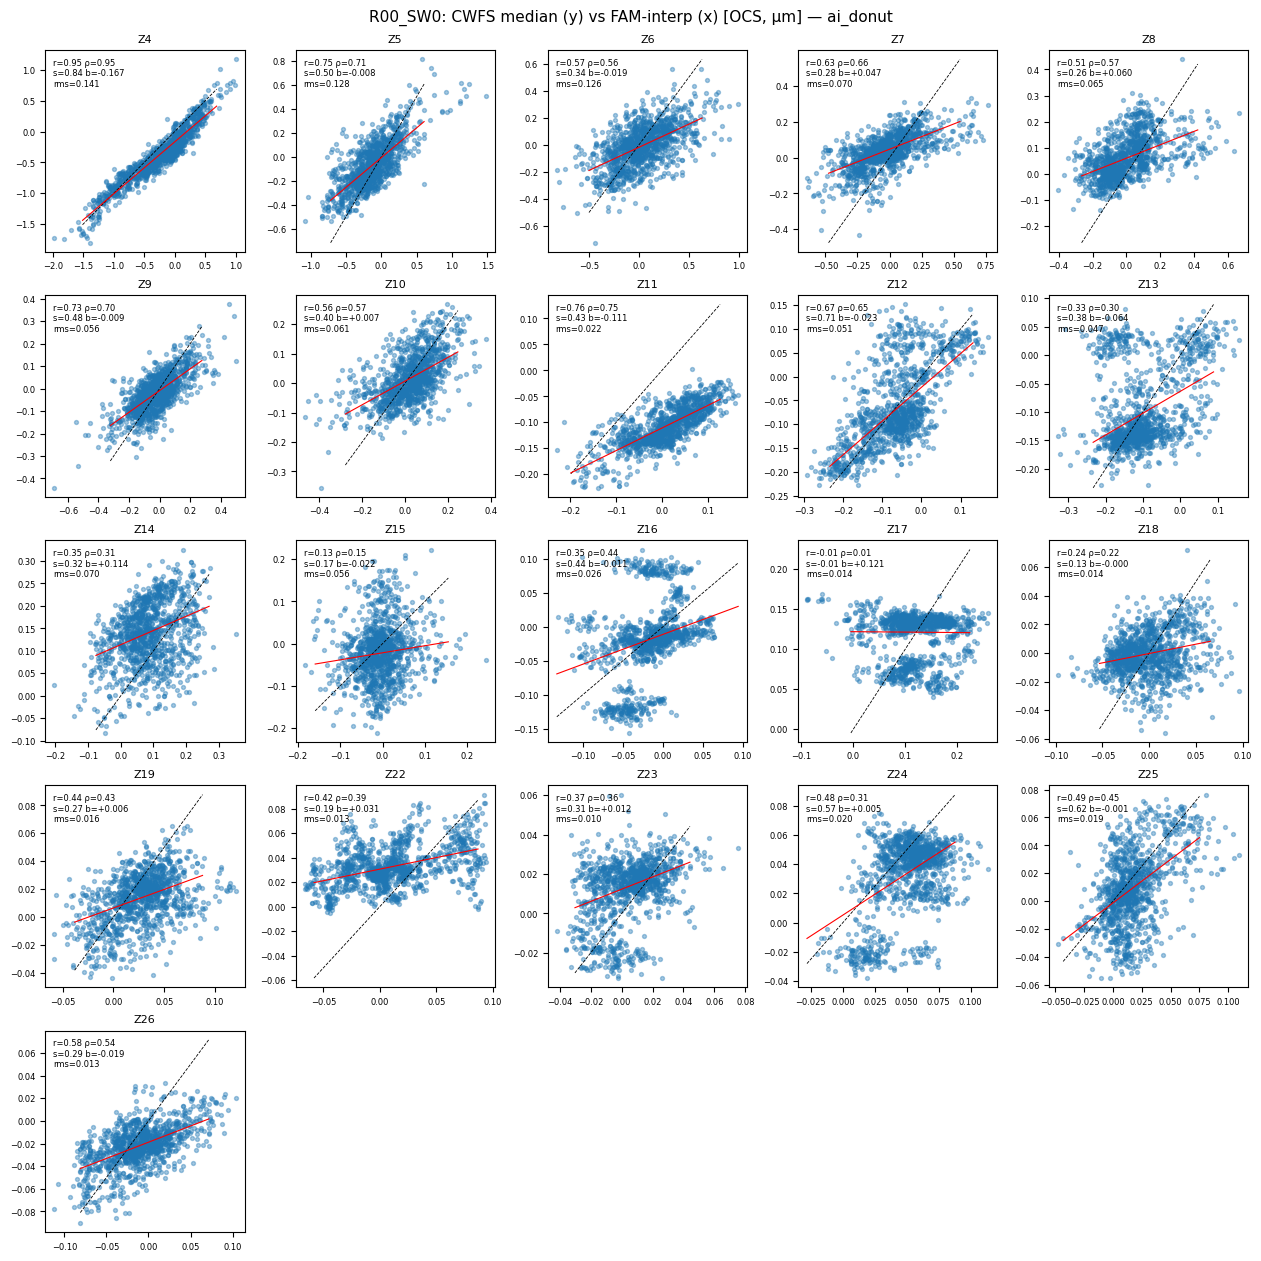

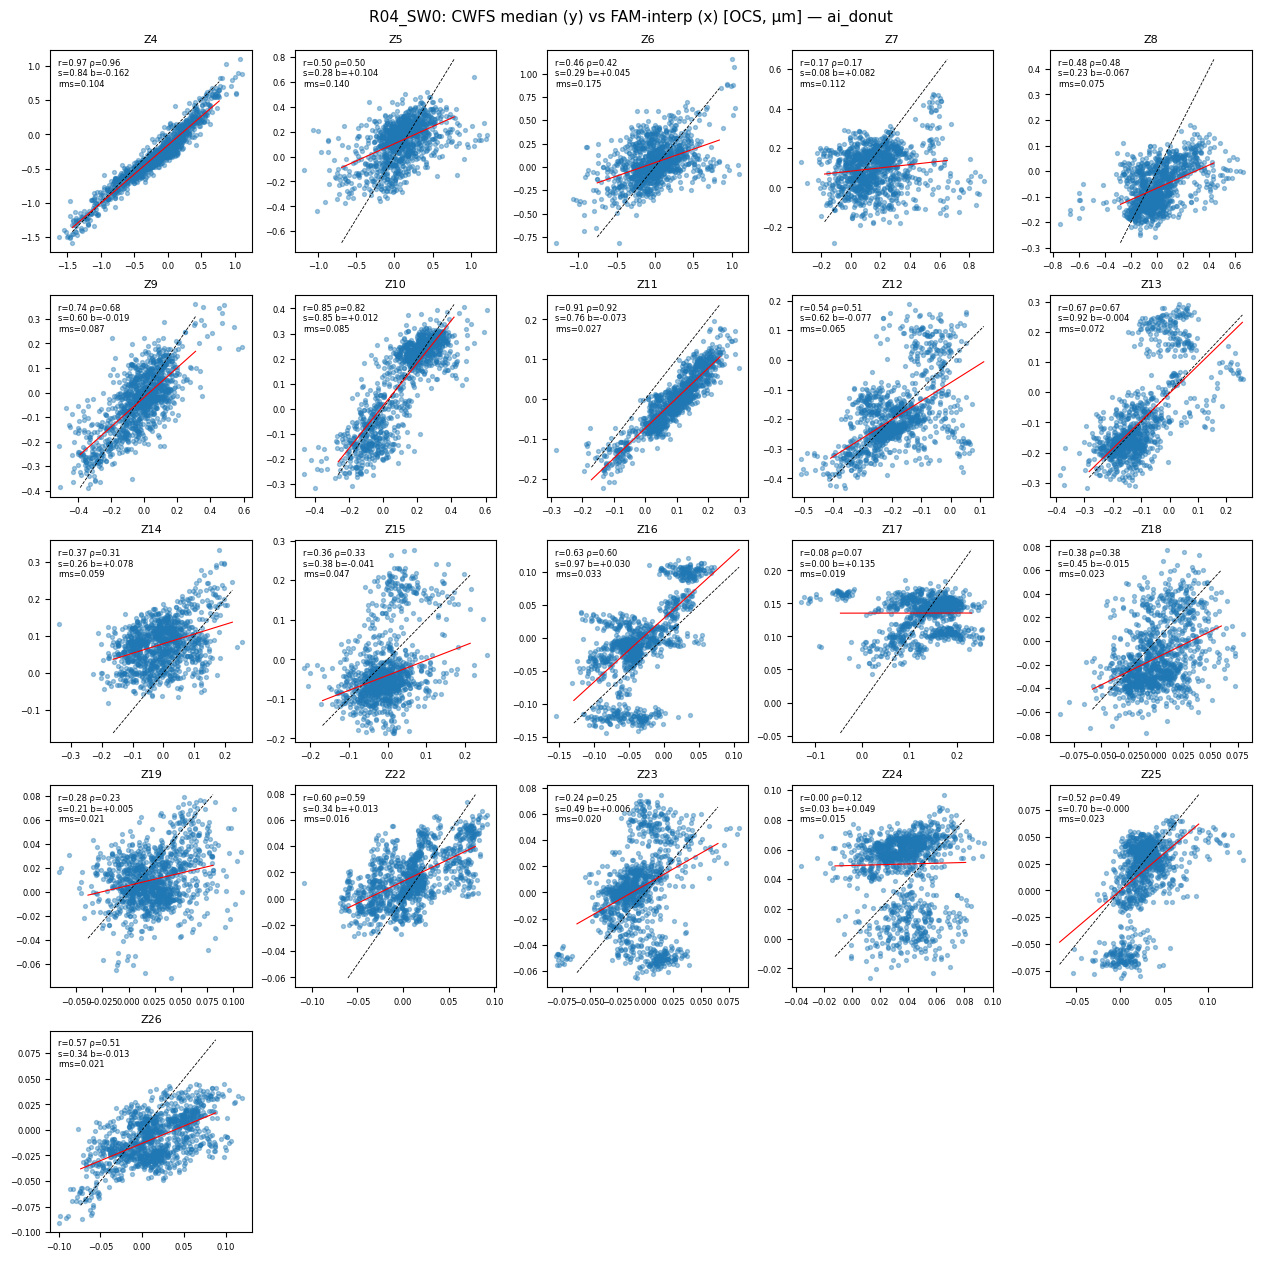

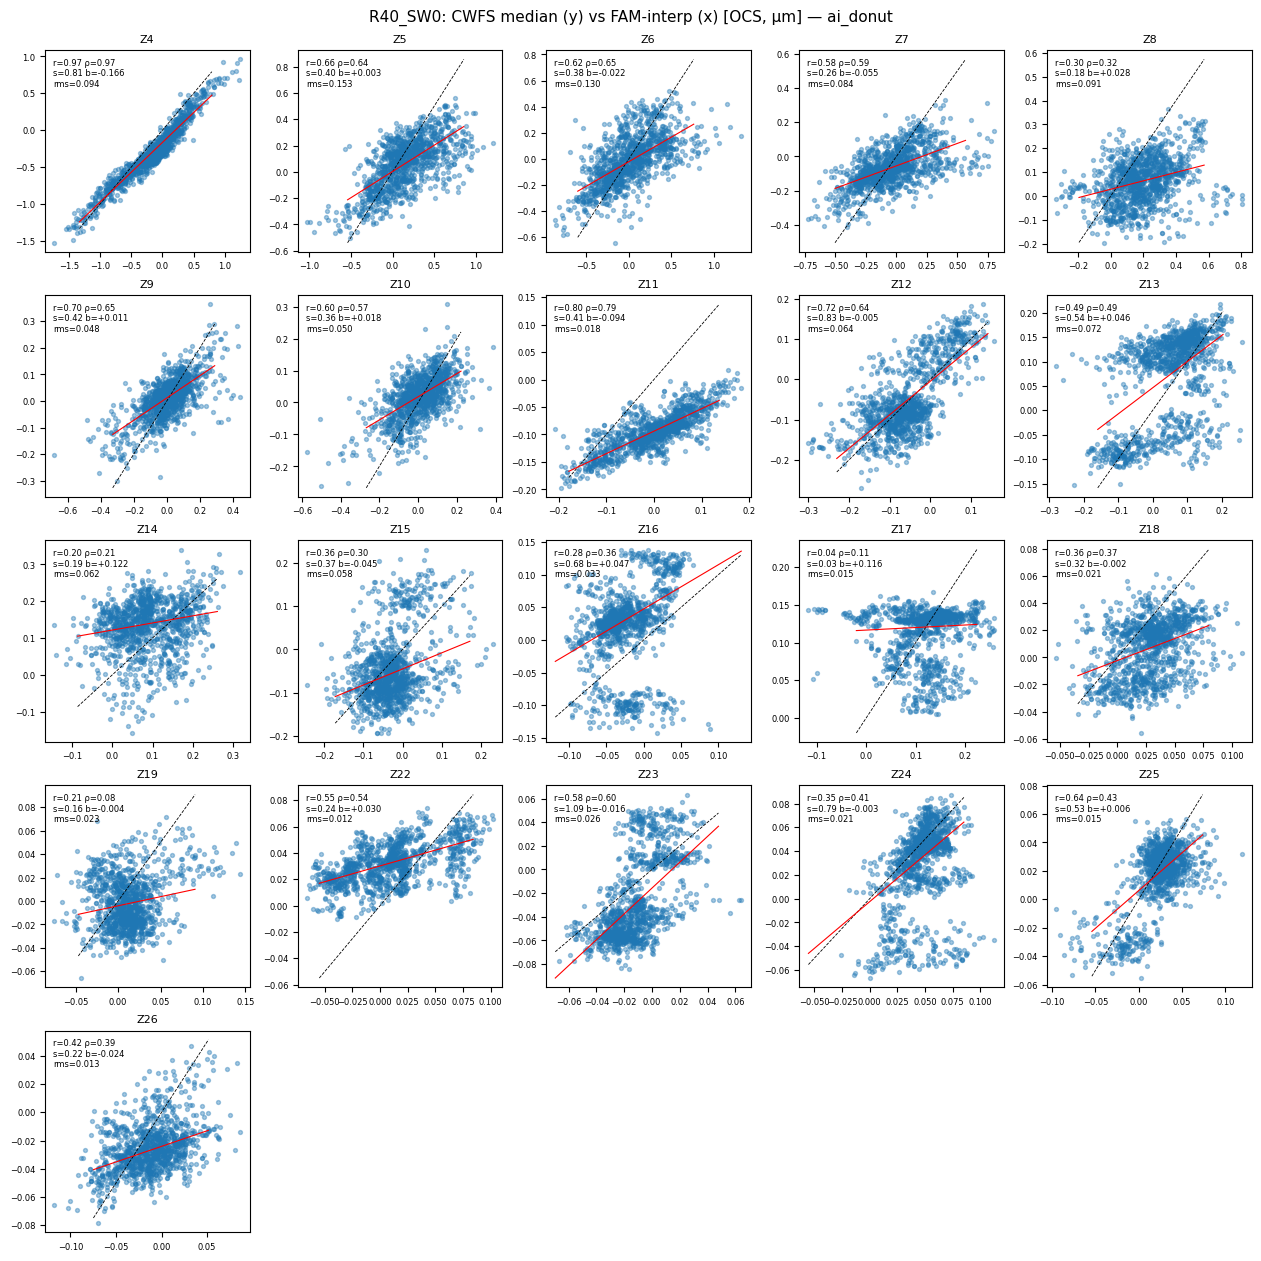

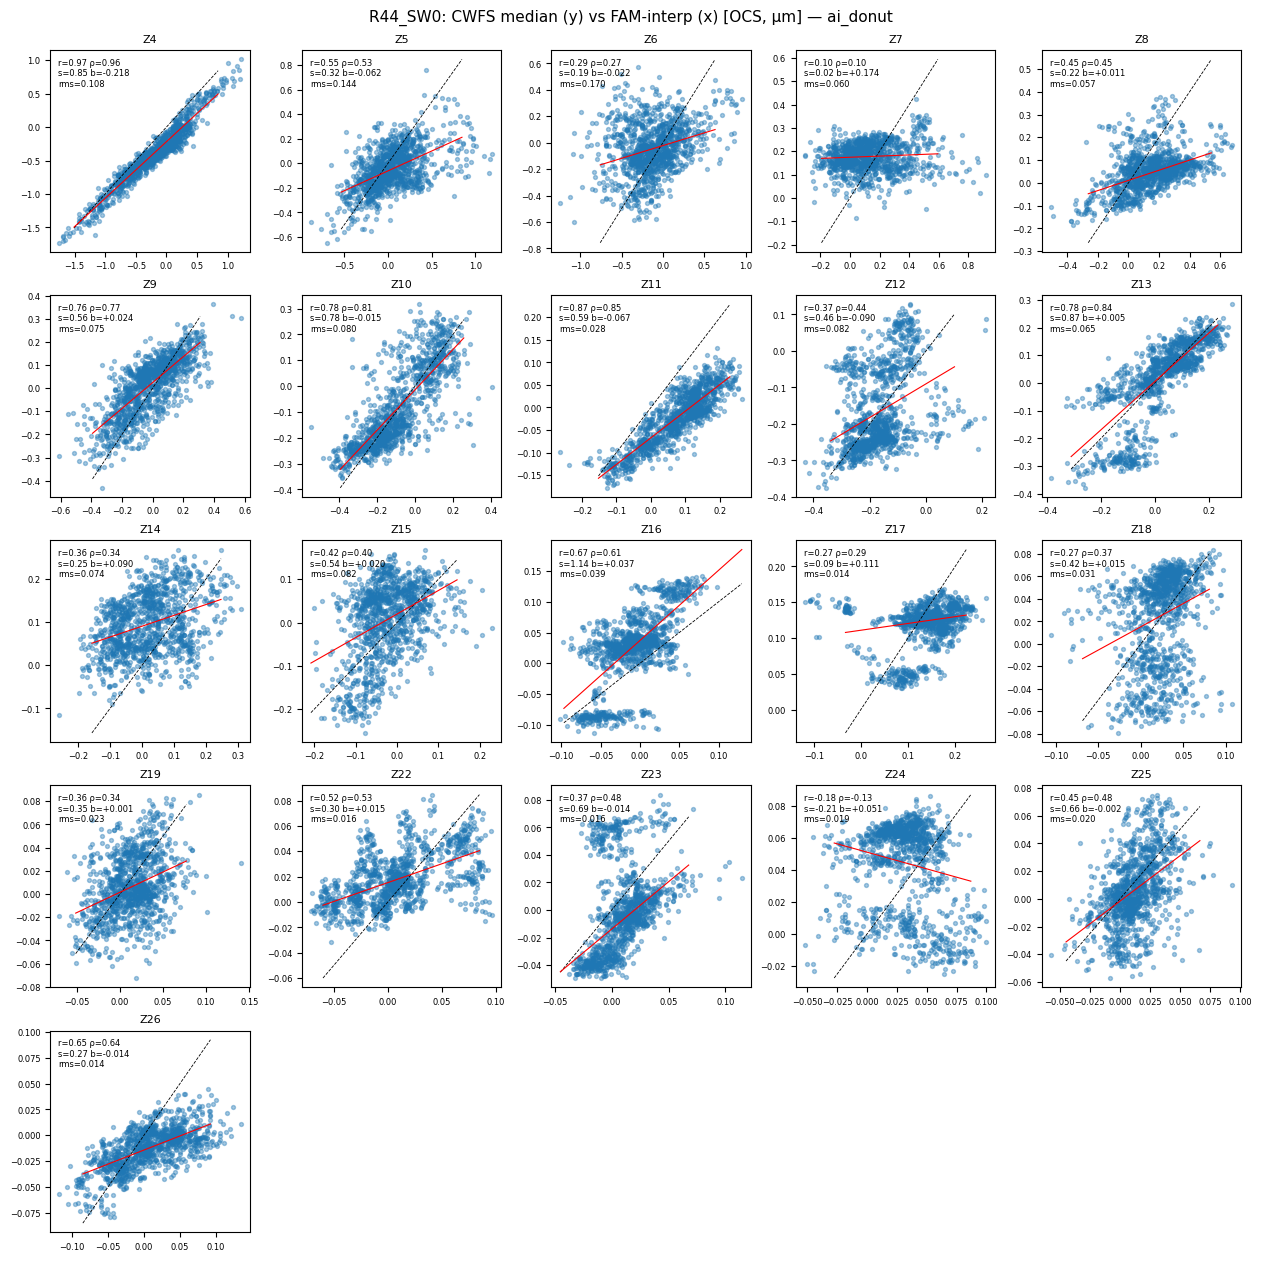

In [4]:
metrics = {}
for c, det in enumerate(CORNERS):
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.5 * nrow), squeeze=False,
                             constrained_layout=True)
    for p, j in enumerate(noll):
        ax = axes.ravel()[p]
        x, y = FAMI[:, c, p], CWM[:, c, p]
        mfit = fit_metrics(x, y); metrics[(det, j)] = mfit
        ax.scatter(x, y, s=8, alpha=0.4)
        fin = np.isfinite(x) & np.isfinite(y)
        if fin.sum() >= 3:
            lo, hi = np.nanpercentile(np.concatenate([x[fin], y[fin]]), [1, 99])
            ax.plot([lo, hi], [lo, hi], 'k--', lw=0.6)
            xx = np.array([lo, hi]); ax.plot(xx, mfit['slope'] * xx + mfit['off'], 'r-', lw=0.8)
            ax.text(0.04, 0.96, f"r={mfit['r']:.2f} \u03c1={mfit['rho']:.2f}\n"
                    f"s={mfit['slope']:.2f} b={mfit['off']:+.3f}\nrms={mfit['rms']:.3f}",
                    transform=ax.transAxes, va='top', fontsize=6)
        ax.set_title(f'Z{j}', fontsize=8); ax.tick_params(labelsize=6)
    for ax in axes.ravel()[len(noll):]:
        ax.axis('off')
    fig.suptitle(f'{det}: CWFS median (y) vs FAM-interp (x) [{COORD}, \u00b5m] \u2014 {WFS_NAME}',
                 fontsize=11)
    plt.show()

<a id='timehist'></a>
## Per-corner time history — pages 5-8

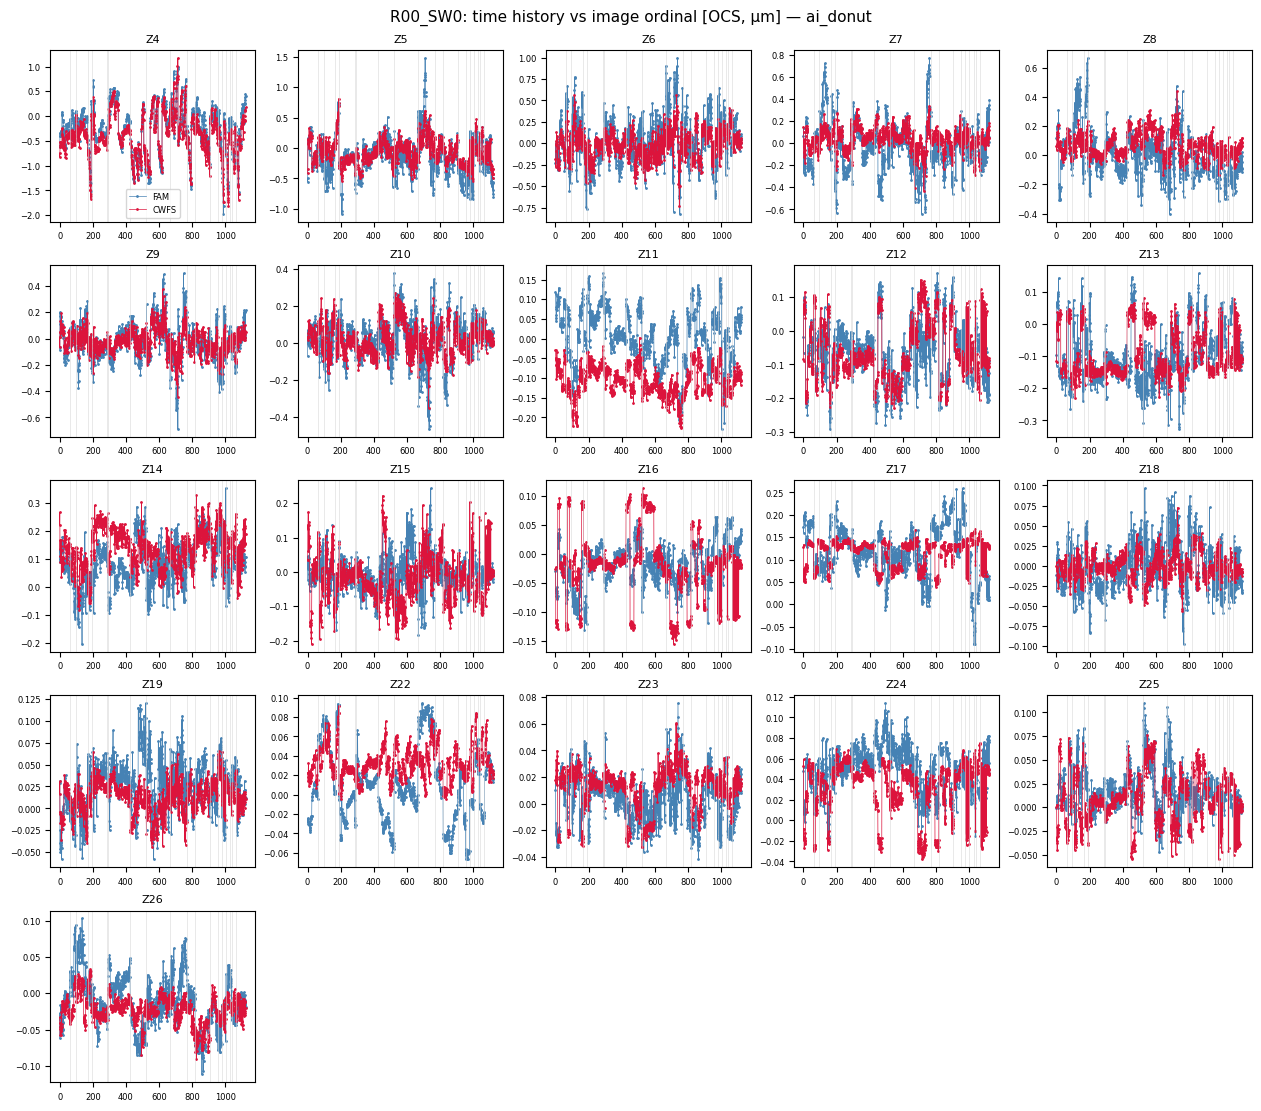

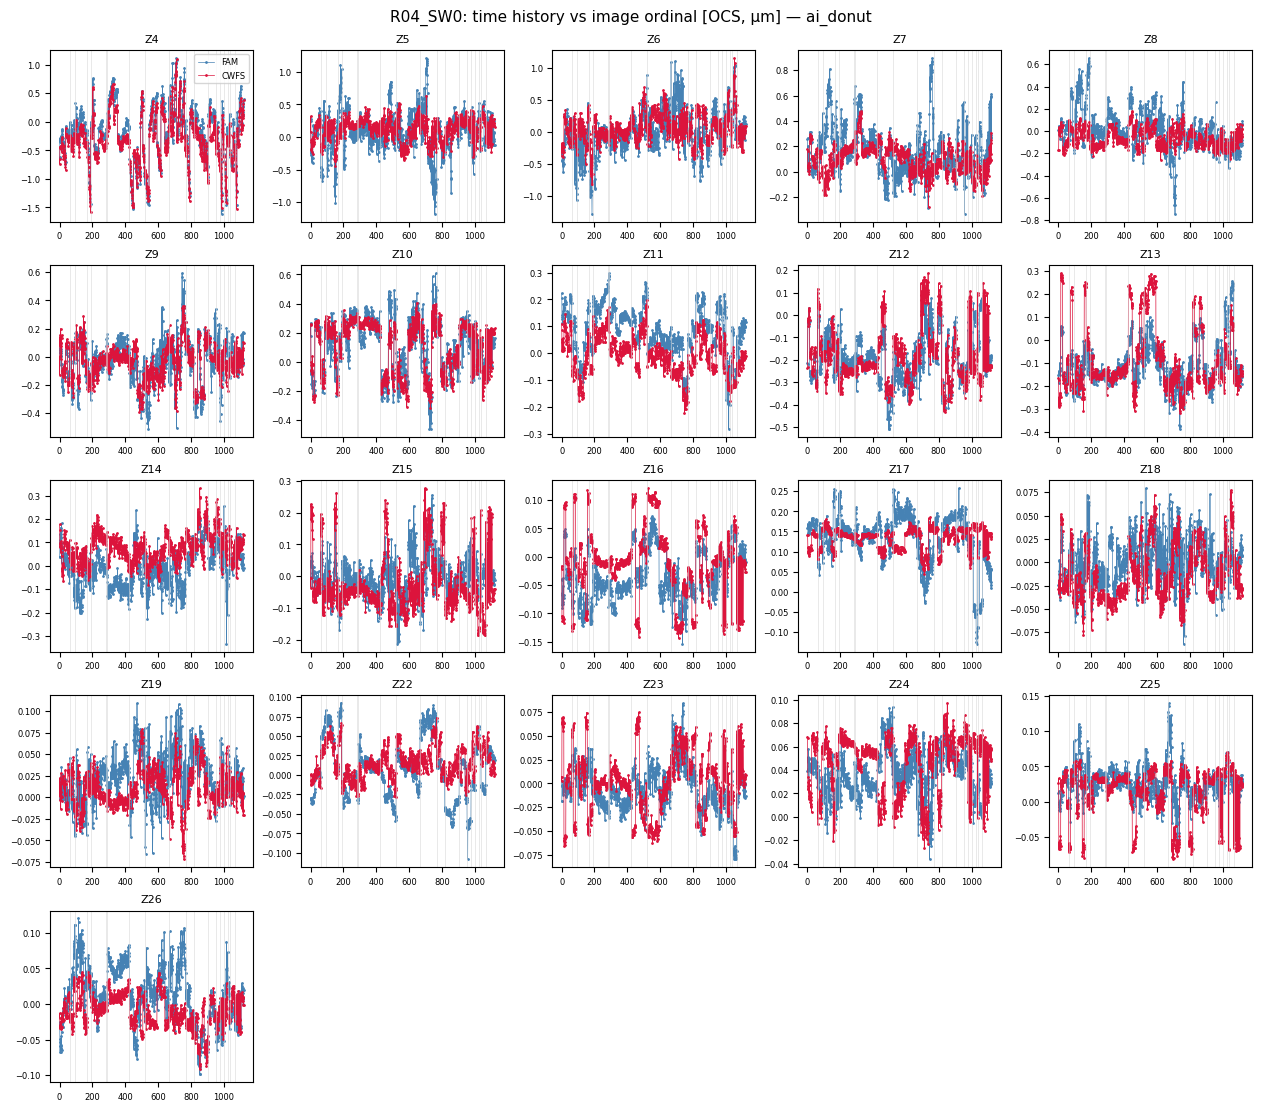

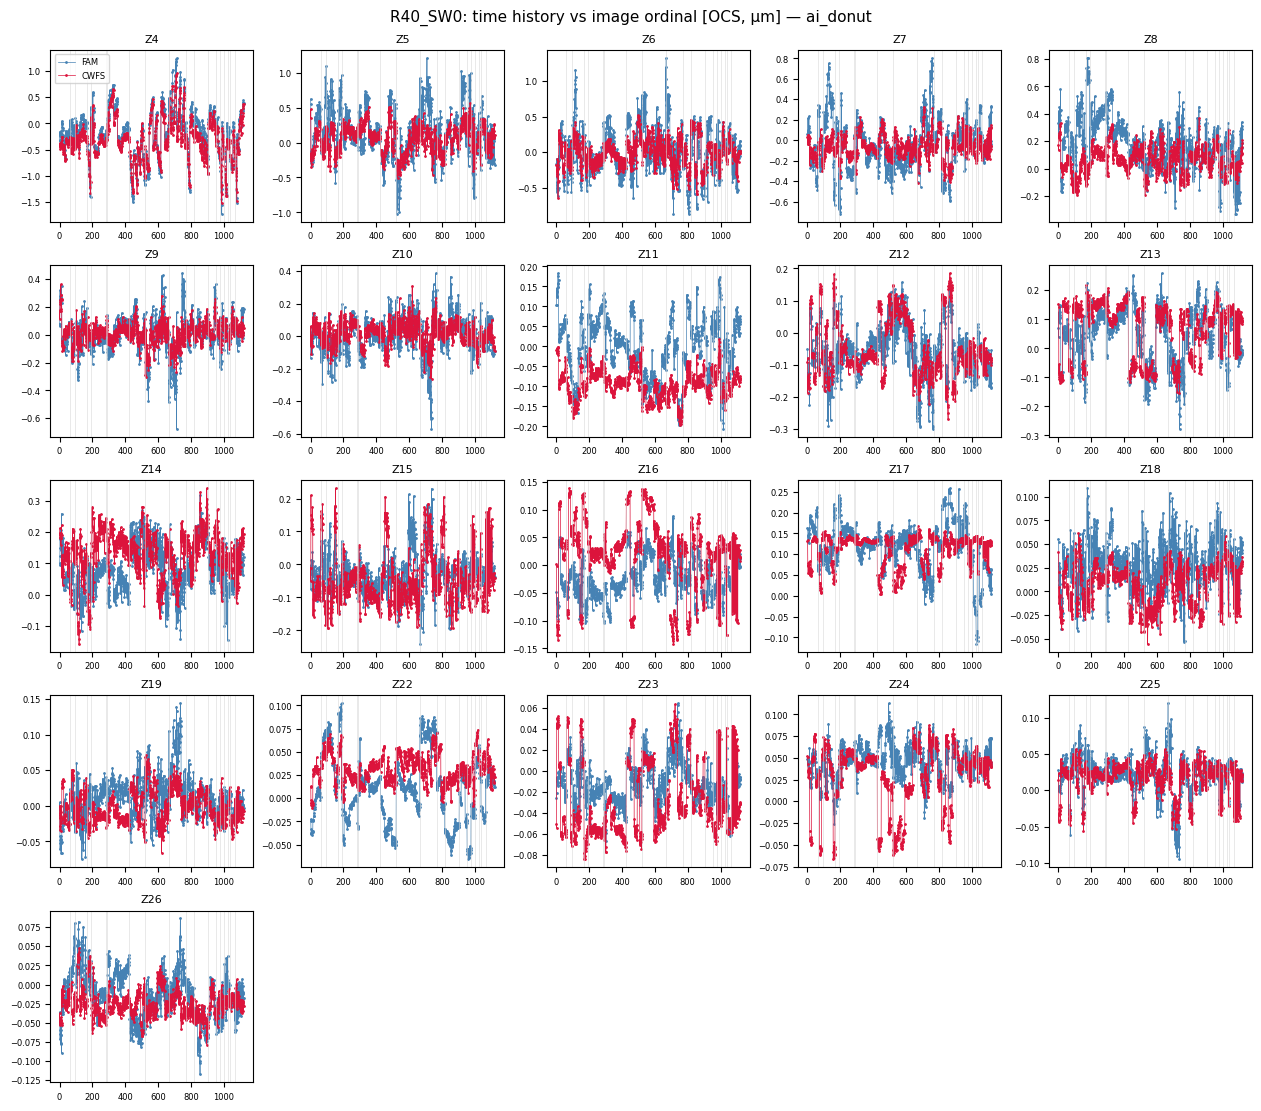

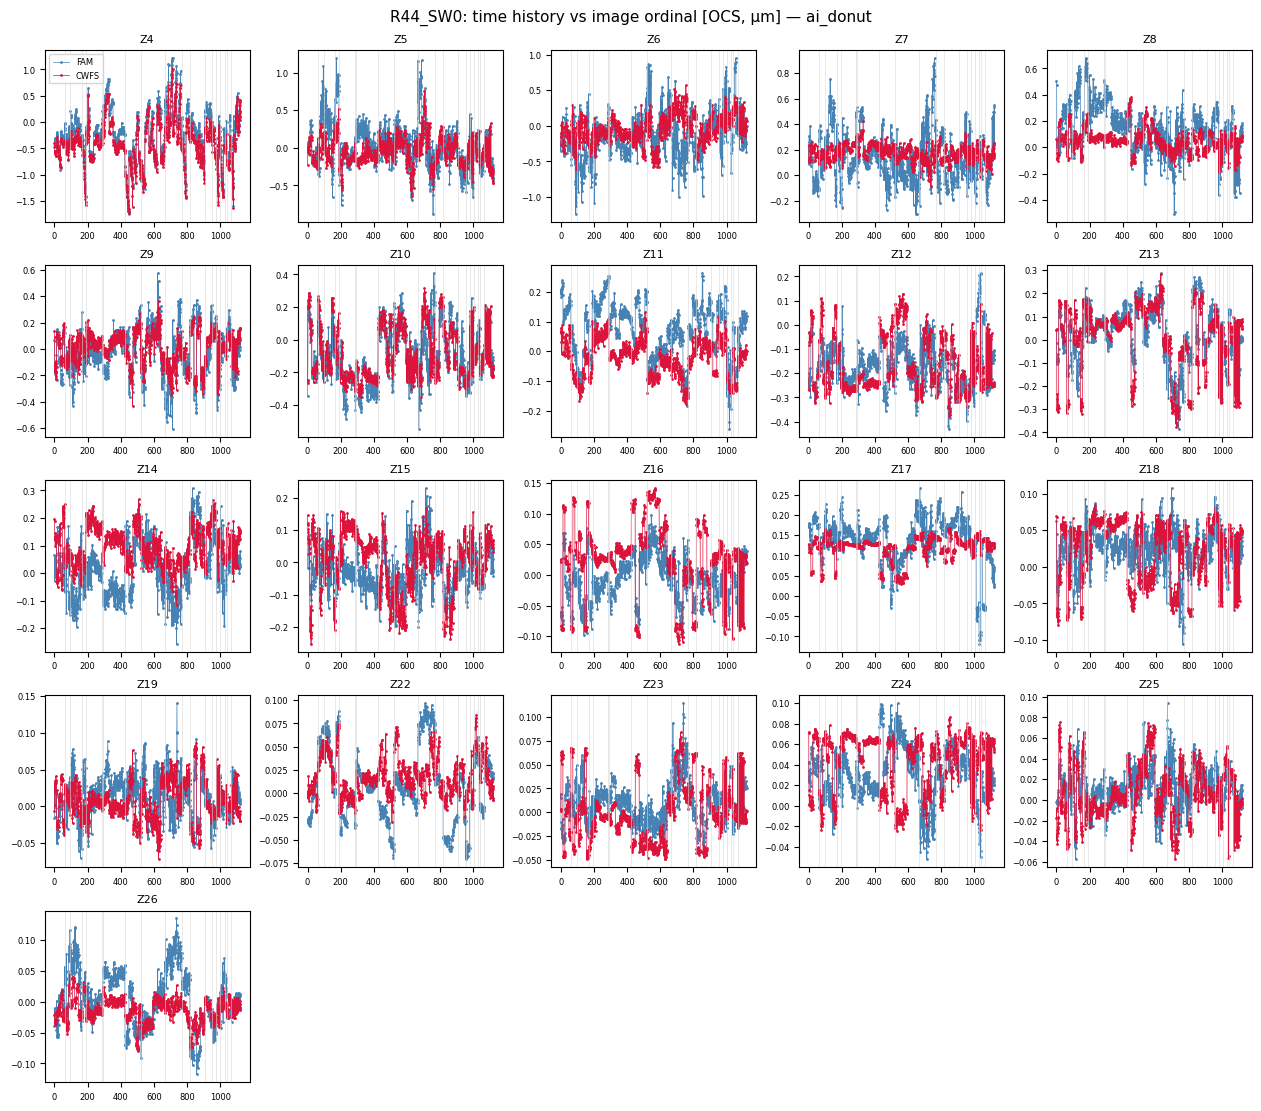

In [5]:
ordn = np.arange(nT)
day_bounds = np.where(np.diff(day_ord) != 0)[0]
for c, det in enumerate(CORNERS):
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.2 * nrow), squeeze=False,
                             constrained_layout=True)
    for p, j in enumerate(noll):
        ax = axes.ravel()[p]
        ax.plot(ordn, FAMI[:, c, p], '.-', ms=2, lw=0.5, color='steelblue', label='FAM')
        ax.plot(ordn, CWM[:, c, p], '.-', ms=2, lw=0.5, color='crimson', label='CWFS')
        for b in day_bounds:
            ax.axvline(b + 0.5, color='0.85', lw=0.4)
        ax.set_title(f'Z{j}', fontsize=8); ax.tick_params(labelsize=6)
    for ax in axes.ravel()[len(noll):]:
        ax.axis('off')
    axes.ravel()[0].legend(fontsize=6)
    fig.suptitle(f'{det}: time history vs image ordinal [{COORD}, \u00b5m] \u2014 {WFS_NAME}',
                 fontsize=11)
    plt.show()

<a id='summary'></a>
## Summary — page 9 (metric vs Zj, all corners)

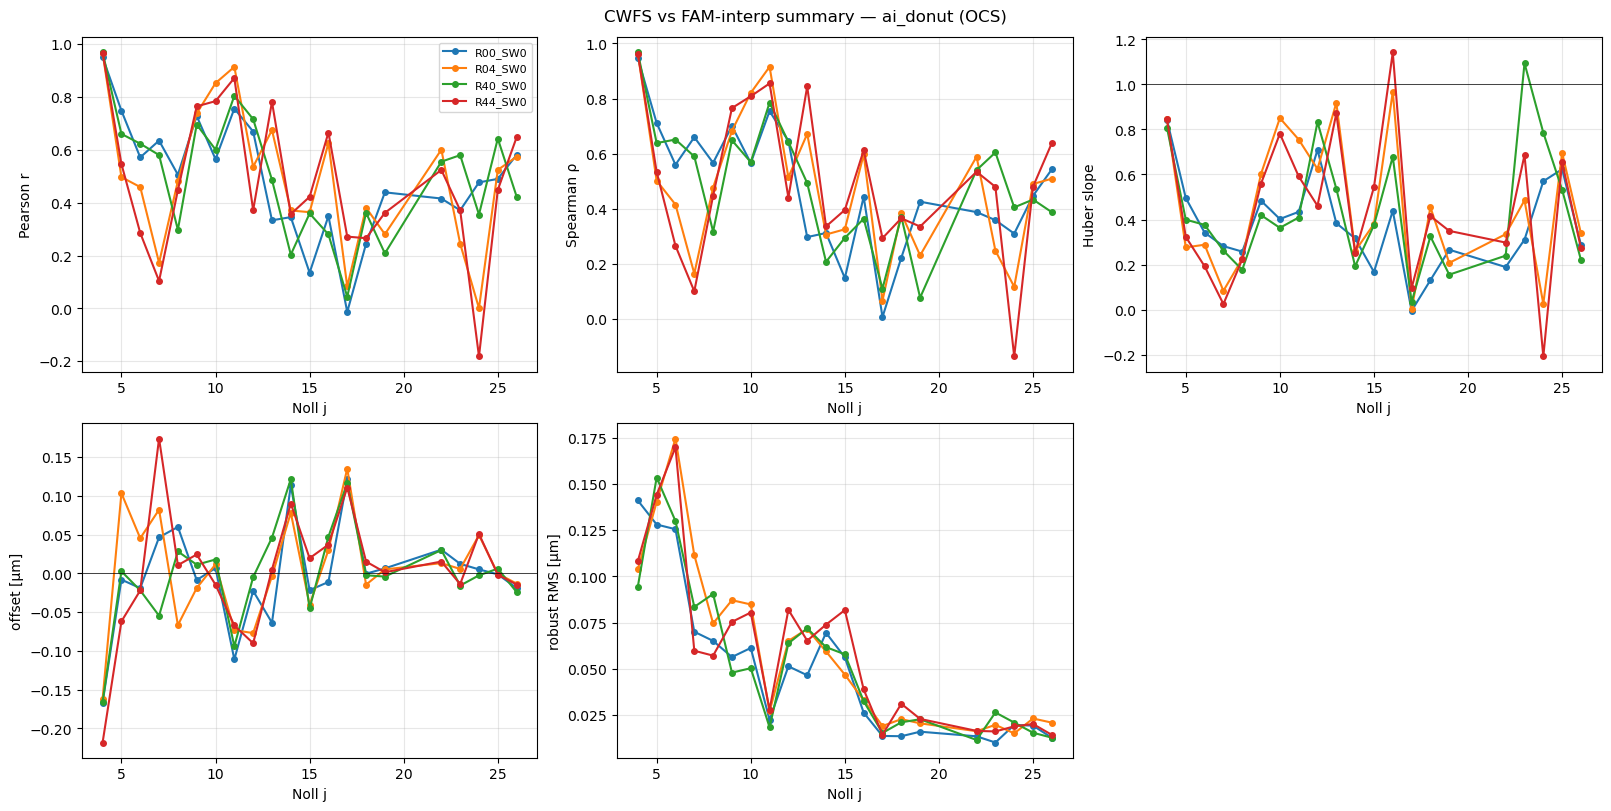

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
panels = [('r', 'Pearson r'), ('rho', 'Spearman \u03c1'), ('slope', 'Huber slope'),
          ('off', 'offset [\u00b5m]'), ('rms', 'robust RMS [\u00b5m]')]
for ax, (key, lab) in zip(axes.ravel(), panels):
    for det in CORNERS:
        ax.plot(noll, [metrics[(det, j)][key] for j in noll], '-o', ms=4, label=det)
    ax.set_xlabel('Noll j'); ax.set_ylabel(lab); ax.grid(alpha=0.3)
    if key == 'slope':
        ax.axhline(1, color='k', lw=0.5)
    if key == 'off':
        ax.axhline(0, color='k', lw=0.5)
axes.ravel()[len(panels)].axis('off')
axes.ravel()[0].legend(fontsize=8)
fig.suptitle(f'CWFS vs FAM-interp summary \u2014 {WFS_NAME} ({COORD})', fontsize=12)
plt.show()